# EDA 3 — Action grammar, session features & visualisations

Each action token has a small grammar:

| Token form | Meaning | Example |
|---|---|---|
| `verb` | what the user did | `Exécution d'un bouton` |
| `verb(screen)` | verb on a given screen (controller) | `Création d'un écran(infologic.core.accueil.AccueilController)` |
| `verb<config>` | screen configuration / mode | `...<TELEM_MINIMAL>` |
| `verb$chain` | functional domain / chain | `...$VT` |
| `tN` | time gap of `N * 5` seconds | `t15` |

Some tokens combine several of these parts. We now quantify each sub-language
and build interpretable per-session features.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from be_ml.data import (
    read_ds, session_features, filter_action, is_time_marker,
    extract, SCREEN_RE, CONFIG_RE, CHAINE_RE,
)

train = read_ds("train")
action_cols = train.columns[2:]

## Split tokens into time markers vs actions

In [2]:
values = train[action_cols].to_numpy().ravel()
flat = pd.Series(values)
tokens = flat[flat.notna()].reset_index(drop=True)
is_t = tokens.map(is_time_marker)
screen_count = int(tokens.str.contains(r"\(", na=False).sum())
chain_count = int(tokens.str.contains(r"\$", na=False).sum())

print(f"total non-null tokens : {len(tokens):,}")
print(f"  - time markers      : {int(is_t.sum()):,}")
print(f"  - actions           : {int((~is_t).sum()):,}")
print(f"tokens containing '(screen)' : {screen_count:,}")
print(f"tokens containing '<config>' : {int(tokens.str.contains('<', na=False).sum()):,}")
print(f"tokens containing '$chain'   : {chain_count:,}")

total non-null tokens : 2,787,933
  - time markers      : 517,686
  - actions           : 2,270,247
tokens containing '(screen)' : 288,454
tokens containing '<config>' : 103,654
tokens containing '$chain'   : 361,680


## The action vocabulary

Stripping the screen/config/chain part leaves the action *verb*. There is a
large but manageable vocabulary; a handful of verbs dominate.

In [3]:
verbs = Counter(filter_action(a) for a in tokens[~is_t])
verb_counts = pd.Series(verbs).sort_values(ascending=False)
print("distinct action verbs:", len(verb_counts))
verb_counts.head(25).to_frame("occurrences")

distinct action verbs: 35


,occurrences
Exécution d'un bouton,510645
Saisie dans un champ,265633
Sélection d'un écran,206813
Fermeture d'une dialogue,171026
Affichage d'une dialogue,168928
Lancement d'une action générique,115283
Sélection d’un onglet,109209
Raccourci,82176
Création d'un écran,76930
Chainage,68194


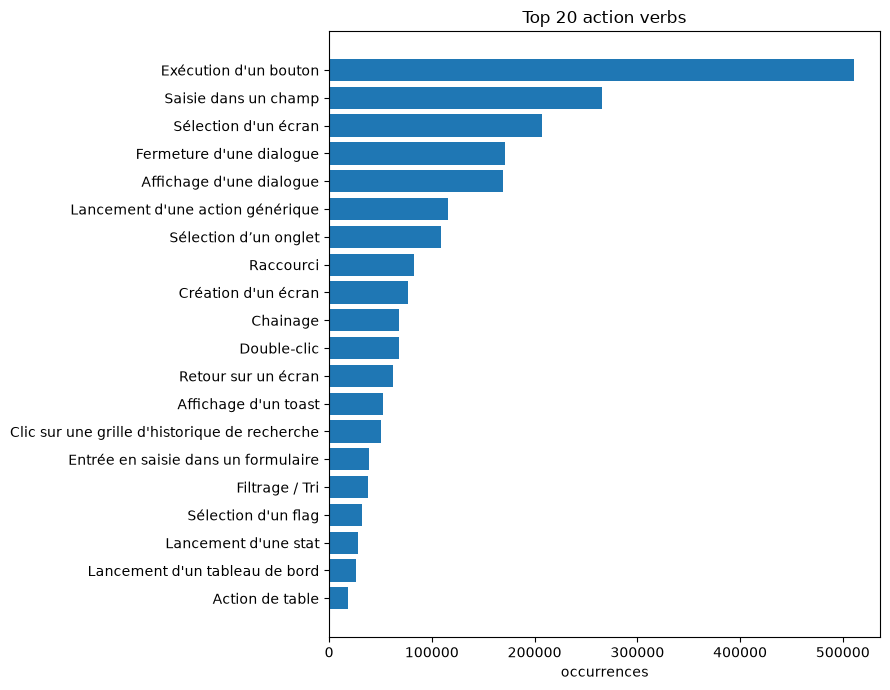

In [4]:
top = verb_counts.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values)
ax.set(xlabel="occurrences", title="Top 20 action verbs")
plt.tight_layout()
plt.show()

## Screens, configurations and chains

- **Screens** (`(...)`) are controller / window identifiers.
- **Configurations** (`<...>`) are display modes or environment settings.
- **Chains** (`$...$`) are functional domains (VT, GP, EDI...): likely strong
  signals of what a given user works on.

In [5]:
screens = Counter(extract(SCREEN_RE, a) for a in tokens[tokens.str.contains(r"\(", na=False)])
configs = Counter(extract(CONFIG_RE, a) for a in tokens[tokens.str.contains("<", na=False)])
chaines = Counter(extract(CHAINE_RE, a) for a in tokens[tokens.str.contains(r"\$", na=False)])

print(f"distinct screens : {len(screens)}")
print(f"distinct configs : {len(configs)}")
print(f"distinct chains  : {len(chaines)}")
pd.Series(chaines).sort_values(ascending=False).to_frame("occurrences")

error: missing ), unterminated subpattern at position 2

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
for ax, counter, title in zip(axs, [screens, configs, chaines], ["Top screens", "Top configs", "Top chains"]):
    s = pd.Series(counter).sort_values(ascending=False).head(12)[::-1]
    ax.barh([str(i)[:38] for i in s.index], s.values)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Time markers

Markers are multiples of 5 seconds. The **maximum marker** of a session gives a
duration proxy; the number of markers indicates how fragmented the session is.

In [ ]:
t_values = tokens[is_t].str[1:].astype(int)
print(f"markers: {len(t_values):,} | distinct values: {t_values.nunique()}")
print(t_values.describe().round(0).to_string())

## Interpretable per-session features

We aggregate each session into a small numeric table with `session_features`
(from `be_ml.data`). These are the natural candidates for a first model.

In [ ]:
features = session_features(train)
features.head()

In [ ]:
features.drop(columns=["util", "navigateur"]).describe().T.round(1)

### Feature correlations

Several size-related features are almost redundant (long sessions have many
actions, many markers and long durations). `n_distinct_*` capture the diversity
of the activity and are less correlated with raw length.

In [ ]:
numeric = features.drop(columns=["util", "navigateur"])
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlation between session features")
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axs, ["n_actions", "duration_seconds", "n_distinct_screens"]):
    ax.hist(features[col], bins=50)
    ax.set_yscale("log")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### A feature for a few users only

Because there are 247 classes, we zoom on the most frequent users. The number of
actions already separates some of them, but the overlap is large: we need
*content*-based features, not just session size.

In [ ]:
top_users = train["util"].value_counts().head(6).index.tolist()
data = [features.loc[features["util"] == u, "n_actions"].values for u in top_users]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=top_users)
ax.set(ylabel="actions per session", title="Session length by user (6 most frequent users)")
plt.tight_layout()
plt.show()

### Chain composition as a discriminative feature

Different users work on different functional domains. For each session we
compute the share of each chain (among the chain-bearing tokens). The heatmap
below shows the **average chain profile per user**: many users have a very
distinctive profile, which is exactly the signal a classifier should exploit.

In [ ]:
values = train[action_cols].to_numpy()
rows = []
for row in values:
    row = row[pd.notna(row)]
    counter = Counter(extract(CHAINE_RE, t) for t in row if "$" in t)
    rows.append(counter)

chain_profile = pd.DataFrame(rows).fillna(0)
chain_profile = chain_profile.div(chain_profile.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
print("chain-profile matrix:", chain_profile.shape, "(sessions x chains)")
chain_profile.head(3)

In [ ]:
top_chaines = chain_profile.sum().sort_values(ascending=False).head(12).index
matrix = chain_profile[top_chaines].copy()
matrix["util"] = train["util"].values
grouped = matrix.groupby("util").mean().loc[top_users]

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(grouped.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(top_chaines)), top_chaines, rotation=45)
ax.set_yticks(range(len(grouped)), grouped.index)
fig.colorbar(im, shrink=0.8, label="share of chain tokens")
ax.set_title("Average chain composition for the 6 most frequent users")
ax.set_xlabel("chain")
ax.set_ylabel("user")
plt.tight_layout()
plt.show()

## Takeaways

- The action vocabulary is structured: ~1.5k verbs, ~400 screens, ~220 configs
  and ~76 chains. Bag-of-actions / count features per session are a natural
  first representation.
- Size features (actions, markers, duration) are highly correlated; add
  diversity features (distinct screens/configs/chains).
- **Chain composition differs strongly across users** and looks like a robust,
  user-specific signature — a great feature family for the classifier.
- Time markers give a duration proxy: `duration_seconds = max(marker) * 5`.

**Next step (modelling):** build a session × feature matrix (bag of verbs /
screens / configs / chains + size features + browser one-hot), then train and
compare classifiers with a **user-wise** train/validation split.